<a href="https://colab.research.google.com/github/aiden-dm/CSCI-4170/blob/main/CSCI_4170_Homework_5_Task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Projects in AI and ML - Homework 5**
##**Aiden Drover-Mattinen**

# Task 1

## Part 1

For this part of the project, I chose to solve the familiar problem of identifying digits, however, I wanted to increase the level of difficulty (and also not use MNIST because of the assignment instructions). As a result, I chose to work with a dataset called The Street View House Numbers (SVHN) Dataset. It contains numbers taken from real houses on Google Street View Images. The combination of the photos being of real life and being RGB makes the digit recognition problem more complicated and interesting to tackle with a CNN.

The dataset can be downloaded using the following link: http://ufldl.stanford.edu/housenumbers/

An even easier way to download the data is using the following commands:


```
wget http://ufldl.stanford.edu/housenumbers/train_32x32.mat
wget http://ufldl.stanford.edu/housenumbers/test_32x32.mat
```



### Preparing the data for the CNN

The first step to solving the problem was to prepare the data. This involved loading it from the downloaded .mat files, fixing the data shape for proper input into the CNN and normalizing.

In [ ]:
import scipy.io
import numpy as np
import tensorflow as tf

def load_svhn_mat(filename):
    data = scipy.io.loadmat(filename)
    images = np.transpose(data['X'], (3, 0, 1, 2))  # Convert (32,32,3,N) → (N,32,32,3)
    labels = data['y'].flatten()
    labels[labels == 10] = 0  # Convert label '10' to '0'
    return images / 255.0, tf.keras.utils.to_categorical(labels, 10)

# Load train/test sets
train_images, train_labels = load_svhn_mat("/content/drive/MyDrive/CSCI4170_Datasets/train_32x32.mat")
test_images, test_labels = load_svhn_mat("/content/drive/MyDrive/CSCI4170_Datasets/test_32x32.mat")

# Convert to TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels)).batch(32).prefetch(tf.data.AUTOTUNE)
test_dataset = tf.data.Dataset.from_tensor_slices((test_images, test_labels)).batch(32).prefetch(tf.data.AUTOTUNE)

As a sanity check of loading the data files, I've printed a few of the test set images below. Notice that the data set is already very clean, so besides normalization and reshaping, no additional pre-processing work is necessary.

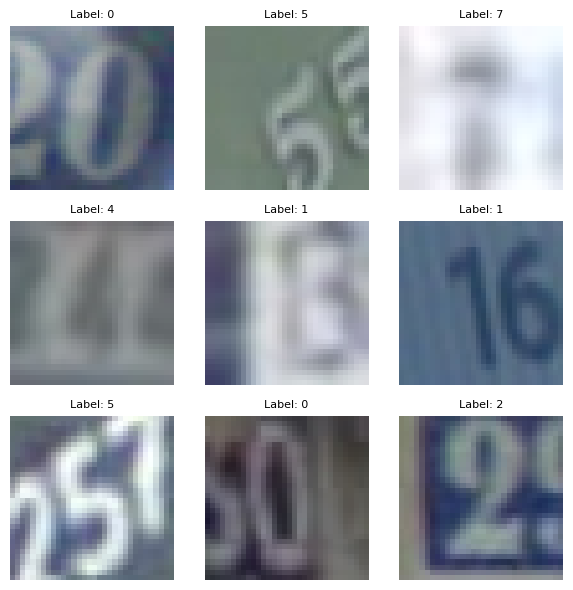

In [ ]:
import matplotlib.pyplot as plt

# Plot some random images
num_images = 9
plt.figure(figsize=(6, 6))

for i in range(num_images):
    plt.subplot(3, 3, i+1)
    idx = np.random.randint(0, len(train_images))
    plt.imshow(train_images[idx])
    plt.title(f"Label: {np.argmax(train_labels[idx])}", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Creating the model

I designed this model to efficiently classify digits in the SVHN dataset by leveraging convolutional layers for hierarchical feature extraction. The first Conv2D block captures low-level patterns like edges, while the second extracts more complex digit structures. Batch normalization stabilizes training, and ReLU activations introduce non-linearity for better learning. Max pooling reduces spatial dimensions, retaining key features while lowering computation. Flattening converts the feature maps into a dense representation, followed by a fully connected layer to refine the learned features before classification. The final softmax layer ensures accurate digit prediction across 10 classes. I believe that this architecture balances efficiency and accuracy for small 32x32 images while minimizing overfitting.

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam

model = Sequential()

# 1st Convolutional Block
model.add(Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# 2nd Convolutional Block
model.add(Conv2D(64, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten the feature maps
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(256, activation='relu'))

# Output Layer
model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_59 (Conv2D)                   │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_60               │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_44 (Activation)           │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_59 (MaxPooling2D)      │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_60 (Conv2D)                   │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_61               │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_45 (Activation)           │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_60 (MaxPooling2D)      │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_23 (Flatten)                 │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_106 (Dense)                    │ (None, 256)                 │       1,048,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_107 (Dense)                    │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,071,178 (4.09 MB)

 Trainable params: 1,070,986 (4.09 MB)

 Non-trainable params: 192 (768.00 B)

With the model created, it can now be trained:

In [ ]:
# Define number of epochs
EPOCHS = 2

# Train the model
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS
)

Epoch 1/2
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 76s 31ms/step - accuracy: 0.6242 - loss: 1.2284 - val_accuracy: 0.7916 - val_loss: 0.7233
Epoch 2/2
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 72s 32ms/step - accuracy: 0.8564 - loss: 0.4811 - val_accuracy: 0.8268 - val_loss: 0.5958


With the training complete, predictions can be made on the test set:

In [ ]:
# Get predictions
predictions = model.predict(test_dataset)

814/814 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step


The predictions can now be processed to evaluate their quality. First I must perform argmax on each prediction to extract the model's digit prediction. I've chosen to print a few of the first predictions to make sure the data is being outputted as expected.

In [ ]:
# Convert predicted probabilities to class indices
y_pred = list(np.argmax(predictions, axis=1))

# Extract true labels from test_dataset
y_true = []
for images, labels in test_dataset:  # Iterate over dataset batches
    y_true.extend(np.argmax(labels.numpy(), axis=1))  # Convert tensors to numpy and get class indices

# Debugging
print("Sample y_true:", y_true[:10])  # Should be integer values
print("Sample y_pred:", y_pred[:10])  # Should be integer values

Sample y_true: [np.int64(5), np.int64(2), np.int64(1), np.int64(0), np.int64(6), np.int64(1), np.int64(9), np.int64(1), np.int64(1), np.int64(8)]
Sample y_pred: [np.int64(5), np.int64(2), np.int64(4), np.int64(0), np.int64(7), np.int64(1), np.int64(9), np.int64(1), np.int64(1), np.int64(8)]


Now that all of the predictions and references are ready, I can generate an sklearn classification report to analyze my model's performance.

In [ ]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_true, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.75      0.81      1744
           1       0.84      0.93      0.88      5099
           2       0.89      0.89      0.89      4149
           3       0.80      0.77      0.78      2882
           4       0.77      0.89      0.83      2523
           5       0.86      0.77      0.81      2384
           6       0.87      0.63      0.73      1977
           7       0.81      0.90      0.85      2019
           8       0.79      0.68      0.73      1660
           9       0.70      0.81      0.75      1595

    accuracy                           0.83     26032
   macro avg       0.82      0.80      0.81     26032
weighted avg       0.83      0.83      0.82     26032



The model performs well overall, achieving 83% accuracy, with particularly strong results for digits 1, 2, and 7 (precision and recall around 90%). However, it struggles with digits 6, 8, and 9, which have lower recall (63% for 6, 68% for 8), likely due to their visual similarity to other digits. The macro F1-score of 81% indicates fairly balanced performance, but misclassifications remain an issue. While increasing the number of epochs could improve performance, limited computational resources constrained training time. Optimizing the architecture, using more efficient training techniques, or leveraging pre-trained models could help refine accuracy without significantly increasing computational cost.

## Part 2

This model builds on my previous approach by leveraging MobileNetV2 as a powerful feature extractor, allowing me to take advantage of pre-trained representations instead of learning features from scratch. Unlike my first model, which used a custom CNN with two convolutional layers, this one benefits from transfer learning, which is especially useful given my computational limitations.

I chose MobileNetV2 over other pre-trained models because it is known for being computationally efficient and relatively quick to train, making it a good fit given my resource constraints. Unlike heavier architectures like ResNet or VGG, MobileNetV2 is optimized for speed while still capturing strong hierarchical features, which helps balance performance and efficiency for my SVHN classification task.

Compared to my first model, which was a custom CNN with only two convolutional layers, this approach leverages transfer learning to extract more robust features without requiring as much training data or time. I also fine-tuned the last 10 layers to allow some adaptation to the SVHN dataset while keeping most of the base model frozen to retain general-purpose feature extraction. The addition of batch normalization helps improve stability, while a lower learning rate (0.0005) and increased dropout help prevent overfitting.

Source: https://www.geeksforgeeks.org/what-is-mobilenet-v2/

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Load MobileNetV2 as feature extractor
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# Unfreeze last few layers for fine-tuning
for layer in base_model.layers[-10:]:
    layer.trainable = True

# Define new model
pre_model = Sequential()

# Add MobileNetV2 as the feature extractor
pre_model.add(base_model)

# Add Global Average Pooling to flatten the output
pre_model.add(GlobalAveragePooling2D())

# Batch Normalization for better stability
pre_model.add(BatchNormalization())

# Custom dense layers with more capacity
pre_model.add(Dense(256, activation='relu'))
pre_model.add(Dropout(0.3))  # Slightly higher dropout

pre_model.add(Dense(128, activation='relu'))
pre_model.add(Dropout(0.2))

# Output layer for classification (10 classes for SVHN)
pre_model.add(Dense(10, activation='softmax'))

# Reduce learning rate for fine-tuning
pre_model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

# Print model summary
pre_model.summary()

<ipython-input-150-b8a96ec64d49>:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))


Model: "sequential_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 1, 1, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_11          │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_59               │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_103 (Dense)                    │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_56 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_104 (Dense)                    │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_57 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_105 (Dense)                    │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,625,226 (10.01 MB)

 Trainable params: 2,588,554 (9.87 MB)

 Non-trainable params: 36,672 (143.25 KB)

Like with the first model, I train this model now that it is defined:

In [ ]:
# Define number of epochs
EPOCHS = 2

# Train the model
history = pre_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS
)

Epoch 1/2
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 311s 119ms/step - accuracy: 0.4252 - loss: 1.7075 - val_accuracy: 0.8128 - val_loss: 0.6184
Epoch 2/2
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 253s 110ms/step - accuracy: 0.8219 - loss: 0.6081 - val_accuracy: 0.8206 - val_loss: 0.6432


Now predictions can be generated:

In [ ]:
# Get predictions
pre_predictions = pre_model.predict(test_dataset)

814/814 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step


In [ ]:
# Convert predicted probabilities to class indices
pre_y_pred = list(np.argmax(pre_predictions, axis=1))

# Extract true labels from test_dataset
pre_y_true = []
for images, labels in test_dataset:  # Iterate over dataset batches
    pre_y_true.extend(np.argmax(labels.numpy(), axis=1))  # Convert tensors to numpy and get class indices

# Debugging
print("Sample y_true:", pre_y_true[:10])  # Should be integer values
print("Sample y_pred:", pre_y_pred[:10])  # Should be integer values

Sample y_true: [np.int64(5), np.int64(2), np.int64(1), np.int64(0), np.int64(6), np.int64(1), np.int64(9), np.int64(1), np.int64(1), np.int64(8)]
Sample y_pred: [np.int64(5), np.int64(2), np.int64(1), np.int64(0), np.int64(6), np.int64(0), np.int64(8), np.int64(1), np.int64(1), np.int64(8)]


With all of the predictions, another classification report can be generated to analyze the performance of the model:

In [ ]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(pre_y_true, pre_y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      1744
           1       0.94      0.89      0.92      5099
           2       0.72      0.98      0.83      4149
           3       0.83      0.81      0.82      2882
           4       0.98      0.63      0.76      2523
           5       0.83      0.85      0.84      2384
           6       0.94      0.60      0.74      1977
           7       0.90      0.84      0.87      2019
           8       0.59      0.83      0.69      1660
           9       0.71      0.66      0.68      1595

    accuracy                           0.82     26032
   macro avg       0.83      0.79      0.80     26032
weighted avg       0.84      0.82      0.82     26032



The MobileNetV2 model performed about the same as my first CNN, with 82% accuracy compared to 83% from the first model. However, the results for individual digits changed. The model recognized digits 2 and 8 much better (recall increased from 89% to 98% for 2 and from 68% to 83% for 8), but it struggled more with digits 4 and 6 (recall dropped from 89% to 63% for 4 and from 63% to 60% for 6).

This shows that MobileNetV2 learns different features than my custom model. It makes fewer mistakes in predicting some digits (higher precision) but misses others more often (lower recall). My first model had more balanced recall across all digits, while this model benefits from transfer learning’s ability to quickly recognize patterns.

If I had more computing power, I could fine-tune more layers or use more data augmentation to improve results. Still, MobileNetV2 was a good choice because it trains faster than other pre-trained models, which helps with my limited resources.

## Part 3

### Implementing Data Augmentation

I applied data augmentation to the training dataset to hopefully help improve model generalization. The augmentation techniques I used include:

* Random Rotation (10%): Rotates images slightly to help the model recognize digits in different orientations.
* Random Zoom (10%): Zooms in or out to make the model more robust to size variations.
* Random Translation (10%): Shifts images in both directions to help the model learn positional variations.

The goal of this augmentation is for the model to see slightly different versions of each digit during training, reducing overfitting and improving performance on unseen data. I only applied augmentation to the training set, since the test set should reflect real-world data without modifications.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

# Data augmentation layer
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.1),           # Rotate up to 10%
    layers.RandomZoom(0.1),               # Zoom in/out up to 10%
    layers.RandomTranslation(0.1, 0.1),   # Shift up to 10% in both directions
])

# Apply augmentation to only the training dataset
def aug_preprocess(image, label):
    image = data_augmentation(image, training=True)  # Augment only during training
    return image, label

# Apply augmentation to training dataset
aug_train_dataset = (tf.data.Dataset.from_tensor_slices((train_images, train_labels))
                 .map(aug_preprocess, num_parallel_calls=tf.data.AUTOTUNE)  # Apply function
                 .batch(32)
                 .prefetch(tf.data.AUTOTUNE))

# Test dataset should NOT be augmented
aug_test_dataset = (tf.data.Dataset.from_tensor_slices((test_images, test_labels))
                .batch(32)
                .prefetch(tf.data.AUTOTUNE))


With the augmentation complete, I wanted to print out a few of the images to see the appearance of the transformations.

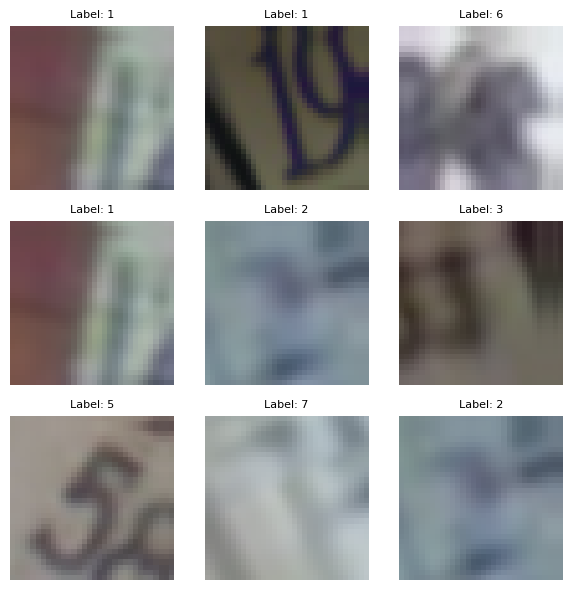

In [ ]:
# Get a batch of images and labels from the dataset
sample_images, sample_labels = next(iter(aug_train_dataset.take(1)))

# Convert from TensorFlow tensors to NumPy arrays
sample_images = sample_images.numpy()
sample_labels = np.argmax(sample_labels.numpy(), axis=1)  # Convert one-hot labels to class indices

# Plot some random images
num_images = 9
plt.figure(figsize=(6, 6))

for i in range(num_images):
    plt.subplot(3, 3, i + 1)
    idx = np.random.randint(0, len(sample_images))  # Randomly select an image from the batch
    plt.imshow(sample_images[idx])
    plt.title(f"Label: {sample_labels[idx]}", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

With the augmentation complete, I've defined another model with the same architecture as the model from Part 1. I want to investigate whether the augmentation improves model training.

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam

aug_model = Sequential()

# 1st Convolutional Block
aug_model.add(Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)))
aug_model.add(BatchNormalization())
aug_model.add(Activation('relu'))
aug_model.add(MaxPooling2D(pool_size=(2,2)))

# 2nd Convolutional Block
aug_model.add(Conv2D(64, (3,3), padding='same'))
aug_model.add(BatchNormalization())
aug_model.add(Activation('relu'))
aug_model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten the feature maps
aug_model.add(Flatten())

# Fully Connected Layer
aug_model.add(Dense(256, activation='relu'))

# Output Layer
aug_model.add(Dense(10, activation='softmax'))

# Compile the model
aug_model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

aug_model.summary()

Model: "sequential_39"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_63 (Conv2D)                   │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_64               │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_48 (Activation)           │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_63 (MaxPooling2D)      │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_64 (Conv2D)                   │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_65               │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_49 (Activation)           │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_64 (MaxPooling2D)      │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_25 (Flatten)                 │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_110 (Dense)                    │ (None, 256)                 │       1,048,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_111 (Dense)                    │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,071,178 (4.09 MB)

 Trainable params: 1,070,986 (4.09 MB)

 Non-trainable params: 192 (768.00 B)

With the model defined, it is time to begin training:

In [ ]:
# Define number of epochs
EPOCHS = 2

# Train the model
history = aug_model.fit(
    aug_train_dataset,
    validation_data=aug_test_dataset,
    epochs=EPOCHS
)

Epoch 1/2
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 83s 35ms/step - accuracy: 0.3434 - loss: 1.9565 - val_accuracy: 0.6809 - val_loss: 0.9980
Epoch 2/2
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 80s 35ms/step - accuracy: 0.6264 - loss: 1.1573 - val_accuracy: 0.7361 - val_loss: 0.9071


With training complete, we can now generate predictions:

In [ ]:
# Get predictions
aug_predictions = aug_model.predict(aug_test_dataset)

814/814 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step


In [ ]:
# Convert predicted probabilities to class indices
aug_y_pred = list(np.argmax(aug_predictions, axis=1))

# Extract true labels from test_dataset
aug_y_true = []
for images, labels in test_dataset:  # Iterate over dataset batches
    aug_y_true.extend(np.argmax(labels.numpy(), axis=1))  # Convert tensors to numpy and get class indices

# Debugging
print("Sample y_true:", aug_y_true[:10])  # Should be integer values
print("Sample y_pred:", aug_y_pred[:10])  # Should be integer values

Sample y_true: [np.int64(5), np.int64(2), np.int64(1), np.int64(0), np.int64(6), np.int64(1), np.int64(9), np.int64(1), np.int64(1), np.int64(8)]
Sample y_pred: [np.int64(5), np.int64(2), np.int64(4), np.int64(0), np.int64(6), np.int64(1), np.int64(9), np.int64(1), np.int64(1), np.int64(8)]


Finally, we can generate a classification report to compare the augmentation model's performance to the regular train set performance:

In [ ]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(aug_y_true, aug_y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.77      0.73      1744
           1       0.89      0.75      0.81      5099
           2       0.85      0.82      0.84      4149
           3       0.67      0.62      0.65      2882
           4       0.61      0.91      0.73      2523
           5       0.80      0.74      0.76      2384
           6       0.81      0.53      0.64      1977
           7       0.79      0.75      0.77      2019
           8       0.52      0.58      0.55      1660
           9       0.58      0.76      0.66      1595

    accuracy                           0.74     26032
   macro avg       0.72      0.72      0.71     26032
weighted avg       0.75      0.74      0.74     26032



The performance of the non-transfer learning model on the augmented dataset dropped compared to its results on the original dataset. Accuracy fell to 74%, and recall decreased for several classes, likely due to the transformations making the digits harder to recognize.

Since SVHN is a relatively clean dataset, with digits centered in the frame, augmentations like translations and zooms may have pushed digits out of their usual position, making them harder for the model to interpret. This likely reduced its ability to learn meaningful patterns, leading to lower accuracy on the test set. While augmentation generally helps with generalization, in this case, it may have disrupted the clarity of the training images too much, ultimately hurting performance.